# Most Streamed Spotify Songs 2023

## 1. Introduction

This project analyzes Spotify song data to understand what factors contribute to a song's success, measured by streams. We explore whether musical characteristics and platform exposure influence popularity.

In [1]:
import babypandas as bpd
import numpy as np

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-colorblind')

spotify = bpd.read_csv("data/spotify-2023.csv", encoding="latin1")
spotify

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
948,My Mind & Me,Selena Gomez,1,2022,11,3,953,0,91473363,61,...,144,A,Major,60,24,39,57,0,8,3
949,Bigger Than The Whole Sky,Taylor Swift,1,2022,10,21,1180,0,121871870,4,...,166,F#,Major,42,7,24,83,1,12,6
950,A Veces (feat. Feid),"Feid, Paulo Londra",2,2022,11,3,573,0,73513683,2,...,92,C#,Major,80,81,67,4,0,8,6
951,En La De Ella,"Feid, Sech, Jhayco",3,2022,10,20,1320,0,133895612,29,...,97,C#,Major,82,67,77,8,0,12,5


## 2. Data Cleaning

The streams column was originally stored as a string. To enable quantative analysis, the column was converted to integers.

In [2]:
def str_to_int(string):
    return int(string)

In [3]:
rank = spotify.sort_values(by = 'streams', ascending = True)
rank = rank.take(np.arange(rank.shape[0] - 1))
rank = rank.assign(streams = rank.get('streams').apply(str_to_int)).sort_values(by = 'streams', ascending = False)
rank

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
55,Blinding Lights,The Weeknd,1,2019,11,29,43899,69,3703895074,672,...,171,C#,Major,50,38,80,0,0,9,7
179,Shape of You,Ed Sheeran,1,2017,1,6,32181,10,3562543890,33,...,96,C#,Minor,83,93,65,58,0,9,8
86,Someone You Loved,Lewis Capaldi,1,2018,11,8,17836,53,2887241814,440,...,110,C#,Major,50,45,41,75,0,11,3
620,Dance Monkey,Tones and I,1,2019,5,10,24529,0,2864791672,533,...,98,F#,Minor,82,54,59,69,0,18,10
41,Sunflower - Spider-Man: Into the Spider-Verse,"Post Malone, Swae Lee",2,2018,10,9,24094,78,2808096550,372,...,90,D,Major,76,91,50,54,0,7,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,Overdrive,Post Malone,1,2023,7,14,410,36,14780425,36,...,140,C#,Major,56,48,73,0,0,35,4
142,"Gol Bolinha, Gol Quadrado 2","Mc Pedrinho, DJ 900",2,2023,6,1,293,8,11956641,5,...,133,B,Minor,93,68,65,42,0,12,25
144,QUEMA,"Sog, Ryan Castro, Peso Pluma",3,2023,7,13,437,31,11599388,17,...,97,NaN,Major,79,92,89,5,0,6,5
393,Jhoome Jo Pathaan,"Arijit Singh, Vishal Dadlani, Sukriti Kakar, V...",6,2022,12,22,138,4,1365184,13,...,105,G,Major,82,62,74,10,0,33,7


## 3. `'streams'` vs. `'mode'`

- **Question:** Is there a significant difference in music streaming counts between songs in major and minor modes?

- To approach this question, we'll look at data from a research study.
    - Each row corresponds to a song.
    - There are two groups of songs: those in the major mode and those in the minor mode.

In [4]:
streams_mode = rank.get(['streams', 'mode'])
streams_mode

,streams,mode
55,3703895074,Major
179,3562543890,Minor
86,2887241814,Major
620,2864791672,Minor
41,2808096550,Major
...,...,...
68,14780425,Major
142,11956641,Minor
144,11599388,Major
393,1365184,Major


### Visualizing the distribution of each group

In [5]:
ma_mode = streams_mode[streams_mode.get('mode') == 'Major']
mi_mode = streams_mode[streams_mode.get('mode') == 'Minor']

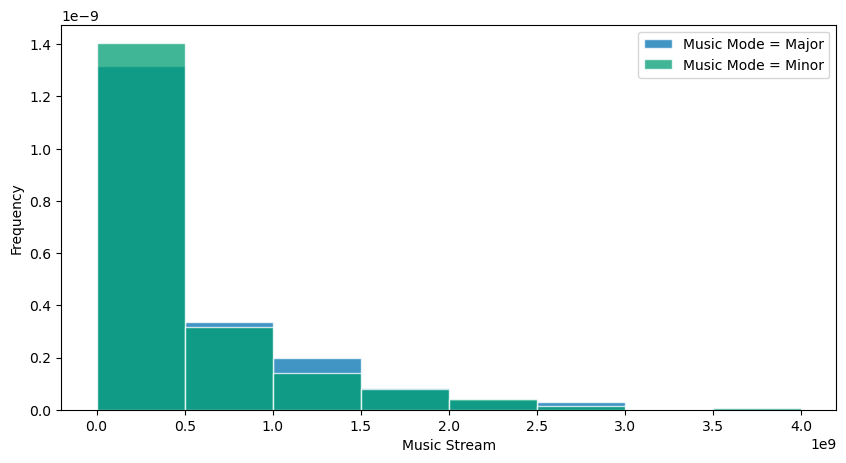

In [6]:
fig, ax = plt.subplots()
ma_mode.plot(kind='hist', density=True, ax=ax, alpha=0.75, bins = np.arange(0, 4.5e9, 0.5e9), ec='w', figsize=(10, 5))
mi_mode.plot(kind='hist', density=True, ax=ax, alpha=0.75, bins = np.arange(0, 4.5e9, 0.5e9), ec='w')
plt.legend(['Music Mode = Major', 'Music Mode = Minor'])
plt.xlabel('Music Stream');

In [7]:
streams_mode.groupby('mode').mean()

,streams
mode,
Major,5.348328e+08
Minor,4.859445e+08


In [8]:
diff_in_mean = (streams_mode.groupby('mode').mean().get('streams').loc['Major'] - 
                streams_mode.groupby('mode').mean().get('streams').loc['Minor'])
diff_in_mean

np.float64(48888314.42448485)

### Setup for the hypothesis test

- **Null Hypothesis**: In the population, the distribution of song streams is the same for both major and minor modes, and the observed differences in our samples are due to random chance.

- **Alternative Hypothesis**: In the population, songs in major mode have higher streams than songs in minor mode, on average. The observed differences in our samples cannot be explained by random chance alone.

- **Test statistic**: Difference in mean songs streams in major mode and minor mode.


$$\substack{\text{mean songs streams in} \\ \text{major mode}} \hspace{0.5in} - \hspace{0.5in} \substack{\text{mean songs streams in} \\ \text{minor mode}}$$

### Permutation tests with DataFrames

- We want to randomly shuffle just the `'mode'` column in the `streams_mode` DataFrame.

In [9]:
streams_mode_with_shuffled = streams_mode.assign(Shuffled_Label = np.random.permutation(streams_mode.get('mode')))
streams_mode_with_shuffled

,streams,mode,Shuffled_Label
55,3703895074,Major,Major
179,3562543890,Minor,Minor
86,2887241814,Major,Minor
620,2864791672,Minor,Major
41,2808096550,Major,Major
...,...,...,...
68,14780425,Major,Major
142,11956641,Minor,Major
144,11599388,Major,Major
393,1365184,Major,Major


Let's look at the distributions of the two new samples we just generated.

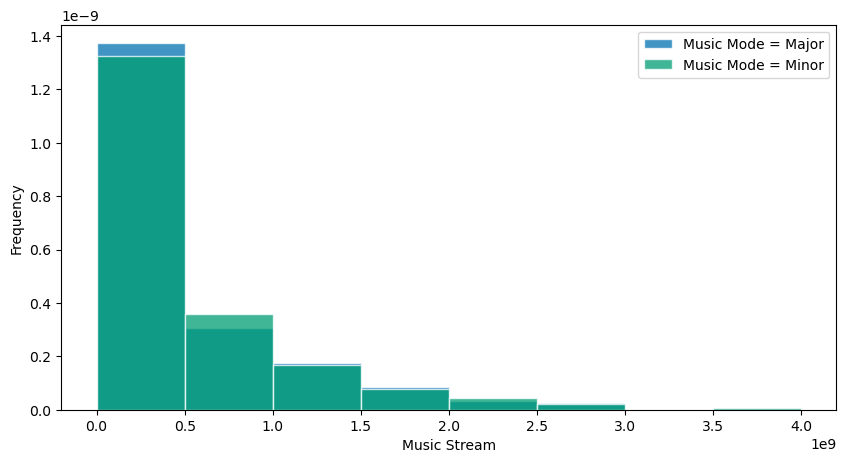

In [10]:
fig, ax = plt.subplots()
ma_mode = streams_mode_with_shuffled[streams_mode_with_shuffled.get('Shuffled_Label') == 'Major']
mi_mode = streams_mode_with_shuffled[streams_mode_with_shuffled.get('Shuffled_Label') == 'Minor']
ma_mode.plot(kind='hist', y='streams', density=True, ax=ax, alpha=0.75, bins = np.arange(0, 4.5e9, 0.5e9), ec='w', figsize=(10, 5))
mi_mode.plot(kind='hist',y='streams', density=True, ax=ax, alpha=0.75, bins = np.arange(0, 4.5e9, 0.5e9), ec='w')
plt.legend(['Music Mode = Major', 'Music Mode = Minor'])
plt.xlabel('Music Stream');

In [11]:
streams_mode_with_shuffled.get(['Shuffled_Label', 'streams']).groupby('Shuffled_Label').mean().get(['streams'])

,streams
Shuffled_Label,
Major,5.129489e+08
Minor,5.157566e+08


In [12]:
group_mean = (streams_mode_with_shuffled.get(['Shuffled_Label', 'streams']).groupby('Shuffled_Label').mean().get('streams').loc['Major'] - 
              streams_mode_with_shuffled.get(['Shuffled_Label', 'streams']).groupby('Shuffled_Label').mean().get('streams').loc['Minor'])
group_mean

np.float64(-2807692.7589797378)

This is the test statistic for one experiment (one "shuffle"). Let's write a function that can compute this test statistic for any shuffle.

In [13]:
def difference_in_group_means(df):
    group_means = df.get(['Shuffled_Label', 'streams']).groupby('Shuffled_Label').mean().get('streams')
    return group_means.loc['Major'] - group_means.loc['Minor']

difference_in_group_means(streams_mode_with_shuffled)

np.float64(-2807692.7589797378)

### Simulation

- This is just one random shuffle.

- We have to repeat the shuffling a bunch of times. On each iteration:
    1. Shuffle the labels to create two new samples.
    2. Add the shuffled labels as a column to the DataFrame.
    3. Compute the difference in group means in the two new samples and store the result.

### Running the simulation

In [14]:
n_repetitions = 500 # The dataset is large, so it takes too long to run if we use 5000 or 10000
differences = np.array([])

for i in np.arange(n_repetitions):
    # Step 1: Shuffle the labels to create two new samples.
    shuffled_label = np.random.permutation(streams_mode.get('mode'))
    
    # Step 2: Add them as a column to the DataFrame.
    shuffled = streams_mode.assign(Shuffled_Label=shuffled_label)
    
    # Step 3: Compute the difference in group means in the two new samples and store the result.
    difference = difference_in_group_means(shuffled)
    
    differences = np.append(differences, difference)
    
differences

array([ 1.40212002e+07, -1.36974583e+07, -5.31411541e+07,  4.41891733e+07,
        4.53460718e+07,  4.39259032e+06,  6.71120739e+07,  1.59365675e+06,
        4.17150784e+07, -5.90032881e+07, -6.05973727e+07,  4.00359117e+07,
        2.80565961e+07, -2.13512315e+07,  5.22153355e+06,  3.56828295e+07,
        5.42816383e+07, -4.81370574e+07,  1.93944972e+07, -1.87081076e+07,
        2.24372585e+07, -2.21881731e+07,  2.03510854e+07,  1.09607264e+07,
        6.16879559e+06,  5.41247636e+07,  4.86131748e+07, -3.43829994e+06,
       -1.08730130e+08, -2.27516669e+07,  2.95703339e+06,  2.09454196e+07,
       -2.19404329e+07,  2.78314957e+07,  5.71451981e+07, -9.50919851e+06,
        3.60567792e+07, -7.44469582e+07,  9.53925379e+05,  3.99658683e+07,
       -2.20401735e+06, -2.01904269e+06,  1.11937868e+06,  7.99996479e+07,
        4.59150180e+07, -4.46388236e+07,  7.76254678e+06,  2.89876298e+07,
       -2.12884783e+07,  6.22603356e+06,  3.27461134e+07,  3.95848114e+07,
       -1.57557830e+07,  

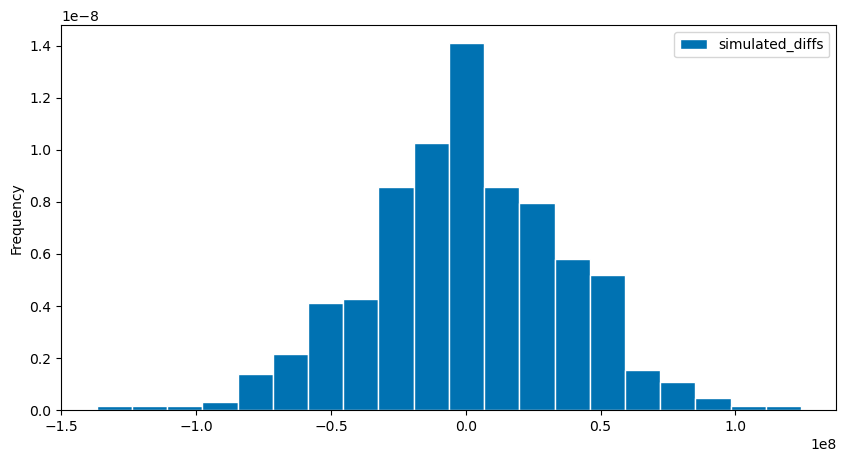

In [15]:
(bpd.DataFrame()
 .assign(simulated_diffs=differences)
 .plot(kind='hist', bins=20, density=True, ec='w', figsize=(10, 5))
);

- Note that the empirical distribution of the test statistic (difference in means) is centered around 0.
- This matches our intuition – if the null hypothesis is true, there should be no difference in the group means on average.

### Conclusion of the test

Where does our observed statistic lie?

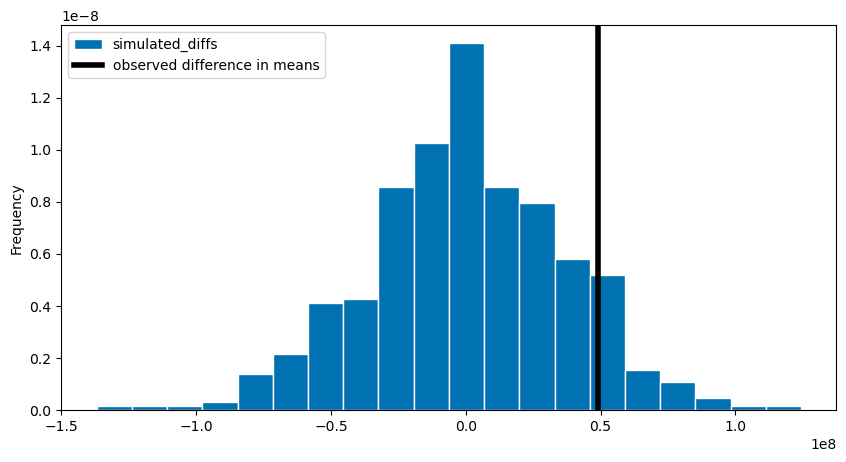

In [16]:
(bpd.DataFrame()
 .assign(simulated_diffs=differences)
 .plot(kind='hist', bins=20, density=True, ec='w', figsize=(10, 5))
);
plt.axvline(diff_in_mean, color='black', linewidth=4, label='observed difference in means')
plt.legend();

In [17]:
p_value = np.count_nonzero(differences >= diff_in_mean) / n_repetitions
p_value

np.float64(0.092)

### Conclusion

- The p-value is greater than the significance level of 0.05. Therefore, we fail to reject the null hypothesis.
- This suggests that there is not enough evidence to support a significant difference in the distribution of song streams between songs in major and minor modes.

## 4. `'streams'` vs. `'in_spotify_playlists'`

- **Question:** Is there an association between these two variables? If so, what kind?

(Note: When looking at a scatter plot, we often describe it in the form "$y$ vs. $x$.")

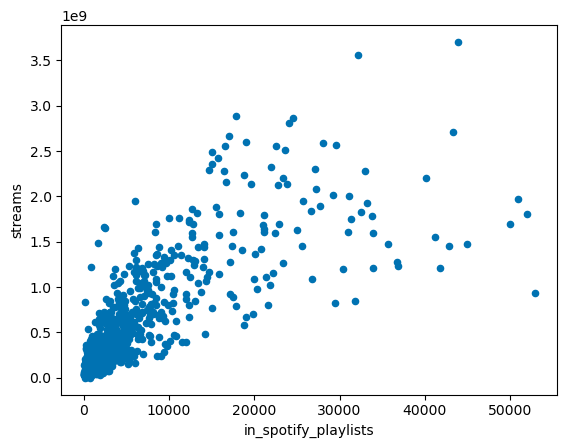

In [18]:
rank.plot(kind='scatter', x='in_spotify_playlists', y='streams');

Let's calculate $r$ for `'streams'` and `'in_spotify_playlists'`.

- $r$ is the average value of the product of $x$ and $y$, when both are measured in **standard units**.

- Recall: Suppose $x$ is a numerical variable, and $x_i$ is one value of that variable. To convert $x_i$ to standard units,
$$x_{i \: \text{(su)}} = \frac{x_i - \text{mean of $x$}}{\text{SD of $x$}}$$

- $r$ is always between $-1$ and $1$.
    - If $r = 1$, the scatter plot of $x$ and $y$ is a line with a positive slope.
    - If $r = -1$, the scatter plot of $x$ and $y$ is a line with a negative slope.
    - If $r = 0$, there is no linear association between $x$ and $y$ (they are _uncorrelated_).

In [19]:
def standard_units(col):
    return (col - col.mean()) / np.std(col)

In [20]:
def calculate_r(df, x, y):
    '''Returns the average value of the product of x and y, 
       when both are measured in standard units.'''
    x_su = standard_units(df.get(x))
    y_su = standard_units(df.get(y))
    return (x_su * y_su).mean()

In [21]:
calculate_r(rank, 'in_spotify_playlists', 'streams')

np.float64(0.7898221599550627)

**Observation**: $r$ is positive, and the association between `'in_spotify_playlists'` and `'streams'` is positive.

### The regression line

- The regression line is the line through $(0,0)$ with slope $r$, when both variables are measured in **standard units**.

$$\text{predicted } y_{\text{(su)}} = r \cdot x_{\text{(su)}}$$

- We use the regression line to make predictions.

- The line in original units
$$\frac{\text{predicted } y - \text{mean of }y}{\text{SD of }y} = r \cdot \frac{x - \text{mean of } x}{\text{SD of }x}$$

- Re-arranging the above equation into the form $\text{predicted } y = mx + b$ yields the formulas:

$$\boxed{m = r \cdot \frac{\text{SD of } y}{\text{SD of }x}, \: \: b = \text{mean of } y - m \cdot \text{mean of } x}$$

- $m$ is the slope of the regression line and $b$ is the intercept.

In [22]:
def slope(df, x, y):
    "Returns the slope of the regression line between columns x and y in df (in original units)."
    r = calculate_r(df, x, y)
    return r * np.std(df.get(y)) / np.std(df.get(x))

def intercept(df, x, y):
    "Returns the intercept of the regression line between columns x and y in df (in original units)."
    return df.get(y).mean() - slope(df, x, y) * df.get(x).mean()

In [23]:
m_str_spolist = slope(rank, 'in_spotify_playlists', 'streams')
m_str_spolist

np.float64(56662.8877355539)

In [24]:
b_str_spolist = intercept(rank, 'in_spotify_playlists', 'streams')
b_str_spolist

np.float64(219345061.2647729)

So, the regression line is

$$\text{predicted music stream} = 56662.89 \cdot \text{number of spotify playlists music in} + 219345061.26$$

### Making predictions

In [25]:
def predict_str(num):
    return m_str_spolist * num + b_str_spolist

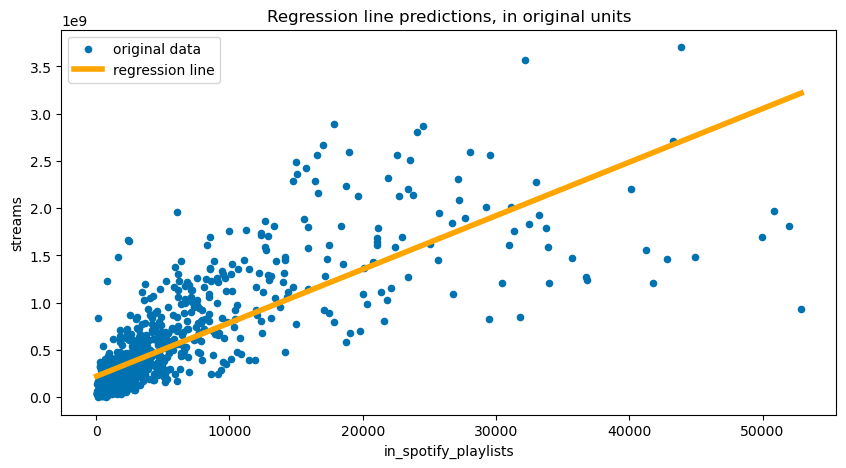

In [26]:
xs = np.arange(rank.get('in_spotify_playlists').min(), rank.get('in_spotify_playlists').max())
ys = predict_str(xs)
rank.plot(kind='scatter', x='in_spotify_playlists', y='streams', figsize=(10, 5), title='Regression line predictions, in original units', label='original data');
plt.plot(xs, ys, color='orange', lw=4, label='regression line')
plt.legend();

### Measuring the error in prediction

- Any set of predictions has _errors_.

$$\text{error} = \text{actual } y - \text{predicted } y$$

- When using the regression line to make predictions, the errors are called **residuals**.
     
$$\text{residual} = \text{actual } y - \text{predicted } y \text{ by regression line}$$

In [27]:
def predicted(df, x, y):
    m = slope(df, x, y)
    b = intercept(df, x, y)
    return m * df.get(x) + b

def residual(df, x, y):
    return df.get(y) - predicted(df, x, y)

In [28]:
predicted_df = rank.get(['streams', 'in_spotify_playlists']).assign(predicted=predicted(rank, 'in_spotify_playlists', 'streams'), 
                                                                    residuals=residual(rank, 'in_spotify_playlists', 'streams'))
predicted_df

,streams,in_spotify_playlists,predicted,residuals
55,3703895074,43899,2.706789e+09,9.971059e+08
179,3562543890,32181,2.042813e+09,1.519730e+09
86,2887241814,17836,1.229984e+09,1.657257e+09
620,2864791672,24529,1.609229e+09,1.255563e+09
41,2808096550,24094,1.584581e+09,1.223516e+09
...,...,...,...,...
68,14780425,410,2.425768e+08,-2.277964e+08
142,11956641,293,2.359473e+08,-2.239906e+08
144,11599388,437,2.441067e+08,-2.325074e+08
393,1365184,138,2.271645e+08,-2.257994e+08


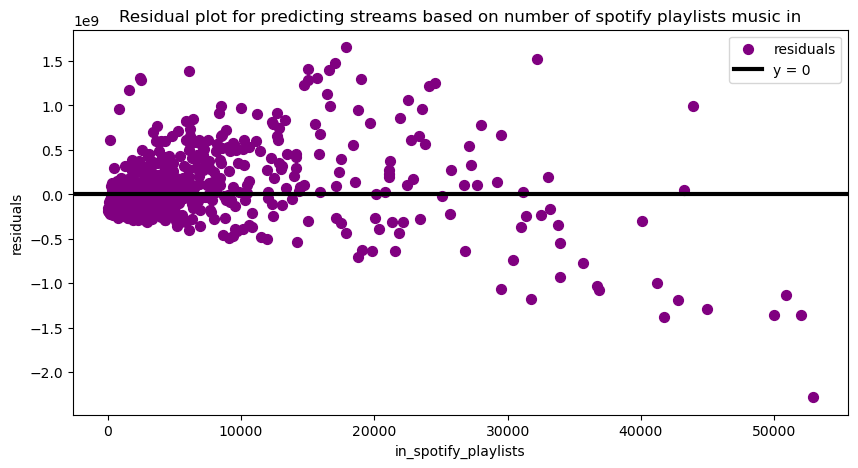

In [29]:
predicted_df.plot(kind='scatter', x='in_spotify_playlists', y='residuals', s=50, c='purple', figsize=(10, 5), label='residuals')
plt.axhline(0, linewidth=3, color='k', label='y = 0')
plt.title('Residual plot for predicting streams based on number of spotify playlists music in')
plt.legend();

### Prediction intervals

We want to come up with a range of reasonable values for a prediction for a single input $x$. To do so, we'll:

1. Bootstrap the sample.
2. Compute the slope and intercept of the regression line for that sample.
3. Repeat steps 1 and 2 many times to compute many slopes and many intercepts.
4. For a given $x$, use the bootstrapped slopes and intercepts to create bootstrapped predictions, and take the middle 95% of them.

The resulting interval is called a **prediction interval**.

In [30]:
m_boot = np.array([])
b_boot = np.array([])

for i in np.arange(5000):
    # Step 1: Resample the dataset.
    resample = rank.sample(rank.shape[0], replace=True)
    
    # Step 2: Compute the slope and intercept of the regression line for that resample.
    m = slope(resample, 'in_spotify_playlists', 'streams')
    b = intercept(resample, 'in_spotify_playlists', 'streams')
    m_boot = np.append(m_boot, m)
    b_boot = np.append(b_boot, b)

In [31]:
boot_preds = m_boot * 68 + b_boot
boot_preds

array([2.31708333e+08, 2.26238151e+08, 2.28158180e+08, ...,
       1.95521305e+08, 2.09289909e+08, 2.18811739e+08], shape=(5000,))

In [32]:
l = np.percentile(boot_preds, 2.5)
r = np.percentile(boot_preds, 97.5)
[l, r]

[np.float64(193042446.3587028), np.float64(249873455.87282777)]

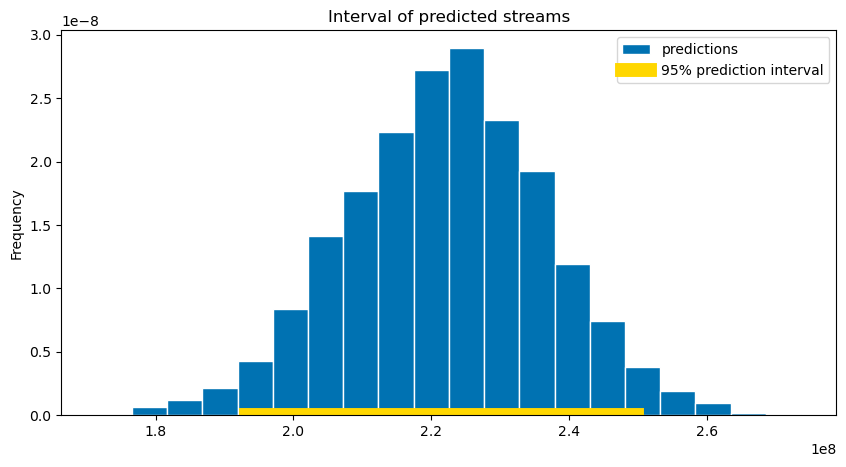

In [33]:
bpd.DataFrame().assign(
    predictions=boot_preds
).plot(kind='hist', density=True, bins=20, figsize=(10, 5), ec='w', title='Interval of predicted streams')
plt.plot([l,r],[0e-8,0e-8], c='gold', linewidth=10, zorder=1, label='95% prediction interval')
plt.legend();

Playlists exposure is the strongest predictor of streams.

### 5. `'streams'` vs. `'bpm'`

Let's now calculate $r$ for `'bpm'` and `'streams'`.

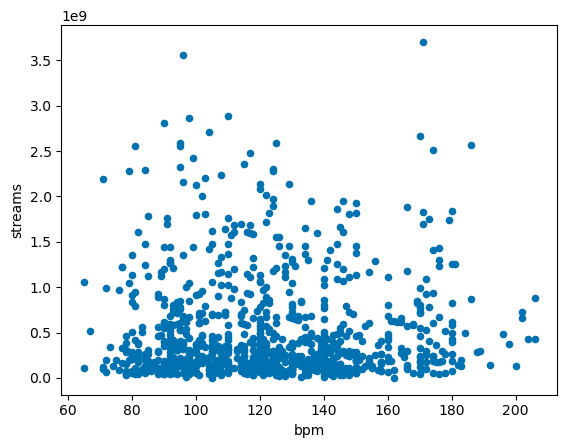

In [34]:
rank.plot(kind='scatter', x='bpm', y='streams');

In [35]:
calculate_r(rank, 'bpm', 'streams')

np.float64(-0.0024379081382717833)

**Observation**: The calculated correlation is −0.0024, which is extremely close to zero. This suggests that there is essentially no linear association between the two variables.

In [36]:
str_bpm = rank.get(['streams', 'bpm']).groupby('bpm').mean()
str_bpm

,streams
bpm,
65,5.838045e+08
67,5.187451e+08
71,8.045134e+08
72,4.185845e+08
73,3.427794e+08
...,...
198,3.732000e+08
200,1.354443e+08
202,6.951332e+08


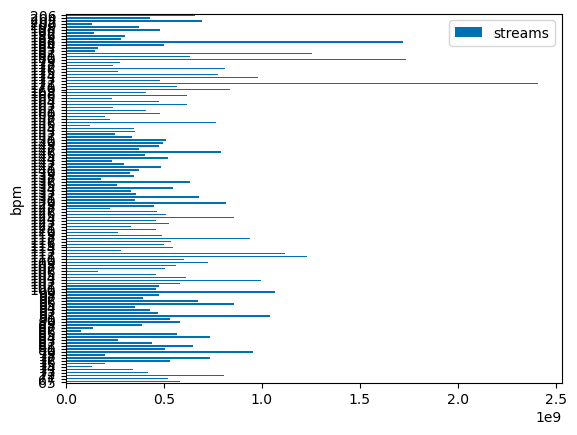

In [37]:
str_bpm.plot(kind='barh', y='streams');

The scatter plot and correlation analysis suggest that bpm has little linear relationship with streams. When grouped into bins, there is still no obvious correlation.

## 6. `'streams'` vs. `'danceability'`

In [38]:
str_dance = rank.get(['danceability_%', 'streams'])
str_dance

,danceability_%,streams
55,50,3703895074
179,83,3562543890
86,50,2887241814
620,82,2864791672
41,76,2808096550
...,...,...
68,56,14780425
142,93,11956641
144,79,11599388
393,82,1365184


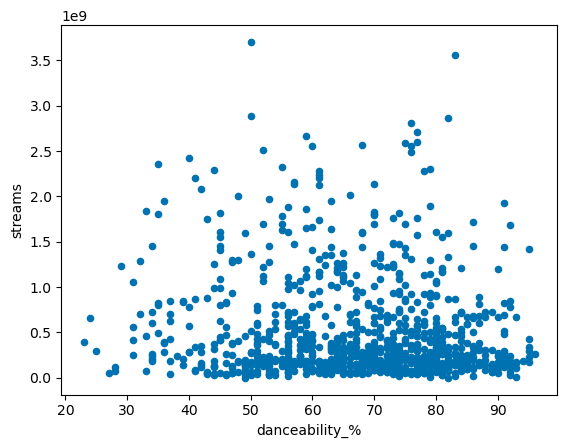

In [39]:
str_dance.plot(kind='scatter', x='danceability_%', y='streams');

In [40]:
str_dance = str_dance.groupby('danceability_%').mean()

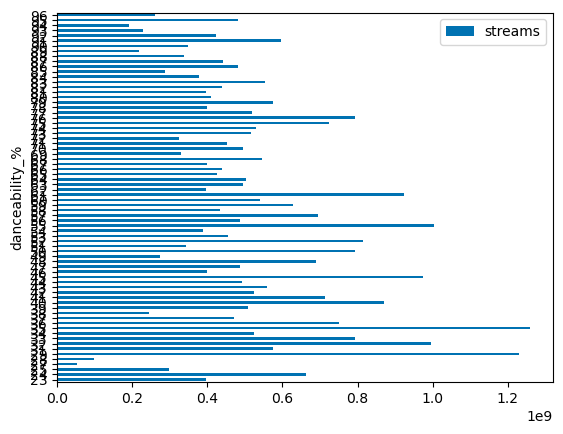

In [41]:
str_dance.plot(kind='barh', y='streams');

Songs were grouped into bins based on their danceability scores, and the average streams for each group were calculated. The resulting bar chart does not show a clear increasing or decreasing trend, indicating that danceability alone may not be a strong predictor of streaming popularity in this dataset.

## 7. `'streams'` vs. `'artist_count'`

In [42]:
str_artist = rank.get(['artist_count', 'streams']).groupby('artist_count').mean()
str_artist

,streams
artist_count,
1,5.682117e+08
2,4.624808e+08
3,3.813421e+08
4,3.061062e+08
5,1.448082e+08
6,8.746645e+07
7,3.390601e+08
8,1.732212e+08


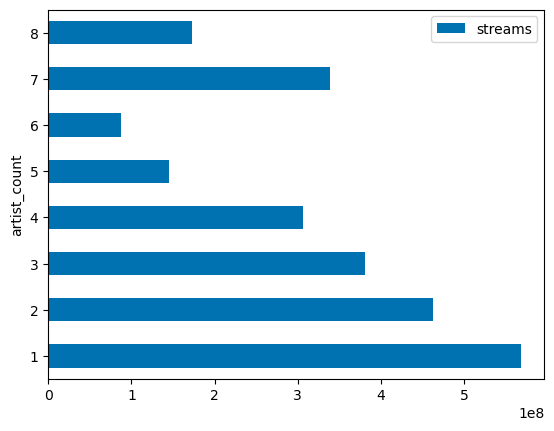

In [43]:
str_artist.plot(kind='barh', y='streams');

## 8. Conclusion

### Key Findings:

- **Mode(Major vs Minor):** The permutation test shows no statistically significant difference in streams between major and minor songs.
- **Playlist Exposure:** There is a strong positive relationship between the number of Spotify playlists and streams; playlist inclusion appears to be the most important factor influencing song popularity.
- **BPM:** BPM has little linear effect on streams.
- **Danceability:** No clear relationships was observed between danceability and steams when grouped, indicating it is not a strong predictor on its own.
- **Artist Count:** No clear relationship; the number of contributing artists does not show a consistent effect on streams.

### Summary
Overall, the analysis suggests that playlist exposure is the primary driver of streaming success, while other features such as song mode, bpm, danceability, and artist count do not show consistent patterns. These insights highlight that distribution and exposure strategies are more influential than intrinsic song characteristics in determining a song’s popularity on Spotify.